# TMDb Lead Actor Origin Analysis

This notebook investigates whether movies with Western and Non-Western lead actors differ in budget, audience rating, and popularity. The analysis first merges the TMDb movie and credits files, enriches lead actors with place-of-birth data from the TMDb API, performs exploratory data analysis, and then runs normality-aware statistical tests.


## 1. Load the TMDb datasets

The movies file contains movie-level variables such as budget, popularity, revenue, runtime, vote average, and vote count. The credits file contains cast information, which is needed to identify the lead actor for each movie.


In [1]:
import ast
import os

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from IPython.display import display
from dotenv import load_dotenv

from scipy.stats import normaltest, shapiro, ttest_ind, mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (9, 5)


In [2]:
movies = pd.read_csv("tmdb_5000_movies.csv")
credits = pd.read_csv("tmdb_5000_credits.csv")

print("Movies shape:", movies.shape)
print("Credits shape:", credits.shape)
movies.head()


Movies shape: (4803, 20)
Credits shape: (4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [3]:
df = movies.merge(credits, on="title")
print("Merged shape:", df.shape)
df.head()


Merged shape: (4809, 23)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


## 2. Extract lead actors

The `cast` column stores a list-like string. The first actor in that list is treated as the lead actor because TMDb credits are ordered by cast billing.


In [4]:
def get_first_actor_info(cast_str):
    cast_list = ast.literal_eval(cast_str)
    if len(cast_list) > 0:
        return pd.Series([cast_list[0]["name"], cast_list[0]["id"]])
    return pd.Series([None, None])


df[["lead_actor", "lead_actor_id"]] = df["cast"].apply(get_first_actor_info)
df[["title", "lead_actor", "lead_actor_id"]].head()


,title,lead_actor,lead_actor_id
0,Avatar,Sam Worthington,65731.0
1,Pirates of the Caribbean: At World's End,Johnny Depp,85.0
2,Spectre,Daniel Craig,8784.0
3,The Dark Knight Rises,Christian Bale,3894.0
4,John Carter,Taylor Kitsch,60900.0


## 3. Enrich lead actors with TMDb API data

The TMDb API is used to retrieve each lead actor's `place_of_birth`. To reduce repeated API calls, the notebook queries each unique lead actor once and then merges the origin classification back into the movie-level dataframe.


In [5]:
load_dotenv()
API_KEY = os.getenv("API_KEY")

if not API_KEY:
    raise ValueError("TMDb API key not found. Add API_KEY=your_key_here to a .env file in the project root.")


def get_actor_origin(actor_id):
    if pd.isna(actor_id):
        return None

    url = f"https://api.themoviedb.org/3/person/{int(actor_id)}?api_key={API_KEY}"

    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
    except requests.RequestException:
        return None

    data = response.json()
    return data.get("place_of_birth")


In [6]:
get_actor_origin(df["lead_actor_id"].iloc[0])


'Godalming, Surrey, England, UK'

## 4. Classify actor origin

Actors are classified as `Western` when their place of birth contains one of the Western country/location keywords below. All other known places of birth are classified as `Non-Western`. Missing places of birth are left as missing and removed before analysis.


In [8]:
western_keywords = [
    "USA", "United States", "America",
    "Canada", "Australia", "New Zealand",
    "UK", "England", "Scotland", "Ireland", "Wales",
    "France", "Germany", "Italy", "Spain", "Portugal",
    "Netherlands", "Belgium", "Switzerland", "Austria",
    "Sweden", "Norway", "Denmark", "Finland",
    "Poland", "Czech", "Slovakia", "Hungary",
    "Greece", "Romania", "Bulgaria",
    "Russia", "Russian"
]


def classify_origin(place):
    if not isinstance(place, str):
        return None

    if "Turkey" in place:
        return "Non-Western"

    for country in western_keywords:
        if country in place:
            return "Western"

    return "Non-Western"


In [9]:
sample = df[["lead_actor", "lead_actor_id"]].head(5).copy()
sample["origin_raw"] = sample["lead_actor_id"].apply(get_actor_origin)
sample["origin"] = sample["origin_raw"].apply(classify_origin)
sample


,lead_actor,lead_actor_id,origin_raw,origin
0,Sam Worthington,65731.0,"Godalming, Surrey, England, UK",Western
1,Johnny Depp,85.0,"Owensboro, Kentucky, USA",Western
2,Daniel Craig,8784.0,"Chester, Cheshire, England, UK",Western
3,Christian Bale,3894.0,"Haverfordwest, Pembrokeshire, Wales, UK",Western
4,Taylor Kitsch,60900.0,"Kelowna, British Columbia, Canada",Western


In [10]:
unique_actors = df[["lead_actor", "lead_actor_id"]].drop_duplicates()
print("Unique lead actors:", len(unique_actors))
unique_actors.head()


Unique lead actors: 2096


,lead_actor,lead_actor_id
0,Sam Worthington,65731.0
1,Johnny Depp,85.0
2,Daniel Craig,8784.0
3,Christian Bale,3894.0
4,Taylor Kitsch,60900.0


In [11]:
unique_actors["origin_raw"] = unique_actors["lead_actor_id"].apply(get_actor_origin)
unique_actors["origin"] = unique_actors["origin_raw"].apply(classify_origin)
unique_actors[["lead_actor", "origin_raw", "origin"]].head()


,lead_actor,origin_raw,origin
0,Sam Worthington,"Godalming, Surrey, England, UK",Western
1,Johnny Depp,"Owensboro, Kentucky, USA",Western
2,Daniel Craig,"Chester, Cheshire, England, UK",Western
3,Christian Bale,"Haverfordwest, Pembrokeshire, Wales, UK",Western
4,Taylor Kitsch,"Kelowna, British Columbia, Canada",Western


In [12]:
unique_actors["origin"].value_counts(dropna=False)


origin
Western        1744
Non-Western     201
NaN             151
Name: count, dtype: int64

In [13]:
df = df.merge(
    unique_actors[["lead_actor_id", "origin"]],
    on="lead_actor_id",
    how="left"
)

print("Before removing missing origin:", df.shape)
df = df.dropna(subset=["origin"]).copy()
print("After removing missing origin:", df.shape)
df["origin"].value_counts()


Before removing missing origin: (4809, 26)
After removing missing origin: (4616, 26)


origin
Western        4291
Non-Western     325
Name: count, dtype: int64

## 5. Exploratory data analysis

The EDA compares group size, central tendency, spread, and relationships between major movie variables. Budgets and popularity are highly skewed, so log-transformed versions are used for distribution and scatter plots where helpful.


In [14]:
eda_df = df.copy()
eda_df["log_budget"] = np.log1p(eda_df["budget"])
eda_df["log_revenue"] = np.log1p(eda_df["revenue"])
eda_df["log_popularity"] = np.log1p(eda_df["popularity"])

origin_order = ["Western", "Non-Western"]
origin_colors = {"Western": "#4c78a8", "Non-Western": "#f58518"}

summary_cols = ["budget", "revenue", "vote_average", "popularity", "runtime", "vote_count"]
eda_df.groupby("origin")[summary_cols].agg(["count", "mean", "median", "std"]).round(2)


budget                                       revenue               \
             count         mean      median          std   count         mean   
origin                                                                          
Non-Western    325  18033587.11   7000000.0  30380634.08     325  46807503.75   
Western       4291  31048759.49  16000000.0  41637459.15    4291  88441722.62   

                                      vote_average        ... popularity  \
                 median           std        count  mean  ...     median   
origin                                                    ...              
Non-Western   4000000.0  1.037762e+08          325  6.28  ...       8.59   
Western      23978402.0  1.686113e+08         4291  6.14  ...      14.23   

                   runtime                       vote_count                 \
               std   count    mean median    std      count    mean median   
origin                                                                       
Non-Western  19.15     324  113.82  107.0  28.73        325  460.95  133.0   
Western      32.88    4291  107.38  104.0  20.84       4291  736.46  273.0   

                      
                 std  
origin                
Non-Western   957.95  
Western      1268.17  

[2 rows x 24 columns]

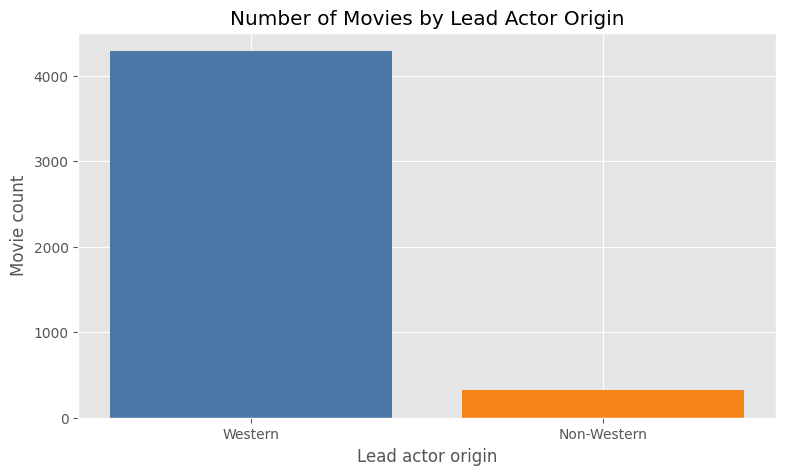

In [15]:
origin_counts = eda_df["origin"].value_counts().reindex(origin_order)

plt.bar(
    origin_counts.index,
    origin_counts.values,
    color=[origin_colors[origin] for origin in origin_counts.index]
)
plt.title("Number of Movies by Lead Actor Origin")
plt.xlabel("Lead actor origin")
plt.ylabel("Movie count")
plt.show()


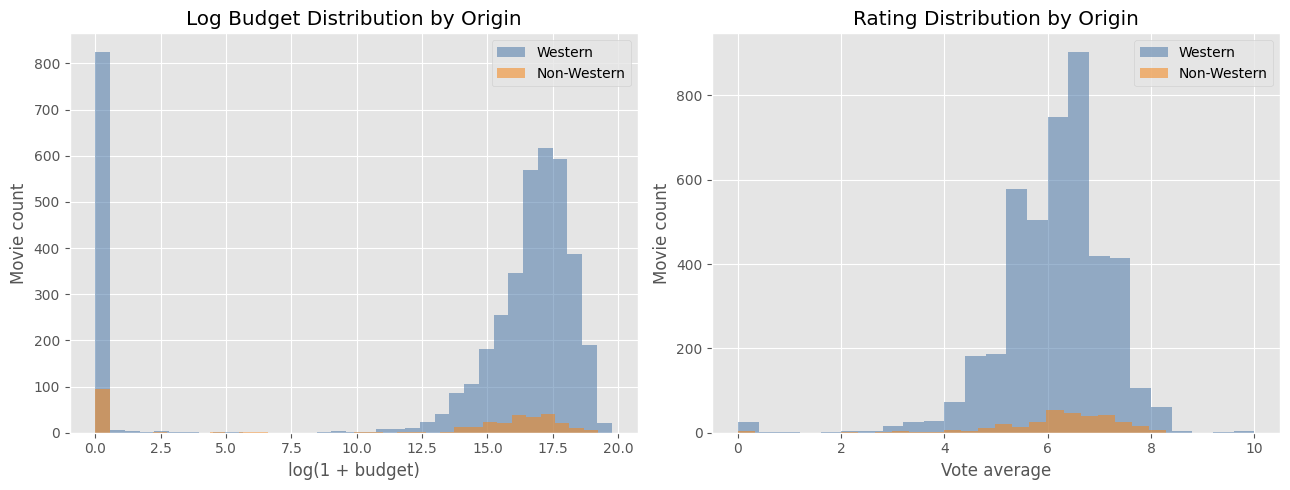

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for origin in origin_order:
    subset = eda_df.loc[eda_df["origin"] == origin]
    axes[0].hist(
        subset["log_budget"].dropna(),
        bins=35,
        alpha=0.55,
        label=origin,
        color=origin_colors[origin]
    )
axes[0].set_title("Log Budget Distribution by Origin")
axes[0].set_xlabel("log(1 + budget)")
axes[0].set_ylabel("Movie count")
axes[0].legend()

for origin in origin_order:
    subset = eda_df.loc[eda_df["origin"] == origin]
    axes[1].hist(
        subset["vote_average"].dropna(),
        bins=25,
        alpha=0.55,
        label=origin,
        color=origin_colors[origin]
    )
axes[1].set_title("Rating Distribution by Origin")
axes[1].set_xlabel("Vote average")
axes[1].set_ylabel("Movie count")
axes[1].legend()

plt.tight_layout()
plt.show()


C:\Users\alink\AppData\Local\Temp\ipykernel_27112\758888343.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  budget_box = axes[0].boxplot(budget_groups, labels=origin_order, patch_artist=True)
C:\Users\alink\AppData\Local\Temp\ipykernel_27112\758888343.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  rating_box = axes[1].boxplot(rating_groups, labels=origin_order, patch_artist=True)


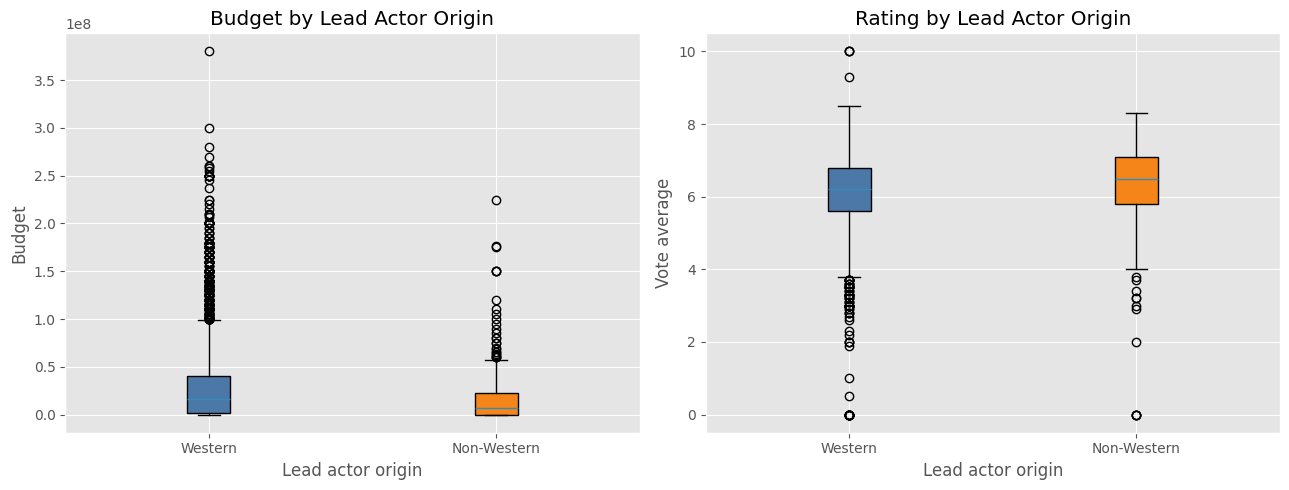

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

budget_groups = [
    eda_df.loc[eda_df["origin"] == origin, "budget"].dropna()
    for origin in origin_order
]
rating_groups = [
    eda_df.loc[eda_df["origin"] == origin, "vote_average"].dropna()
    for origin in origin_order
]

budget_box = axes[0].boxplot(budget_groups, labels=origin_order, patch_artist=True)
for patch, origin in zip(budget_box["boxes"], origin_order):
    patch.set_facecolor(origin_colors[origin])
axes[0].set_title("Budget by Lead Actor Origin")
axes[0].set_xlabel("Lead actor origin")
axes[0].set_ylabel("Budget")

rating_box = axes[1].boxplot(rating_groups, labels=origin_order, patch_artist=True)
for patch, origin in zip(rating_box["boxes"], origin_order):
    patch.set_facecolor(origin_colors[origin])
axes[1].set_title("Rating by Lead Actor Origin")
axes[1].set_xlabel("Lead actor origin")
axes[1].set_ylabel("Vote average")

plt.tight_layout()
plt.show()


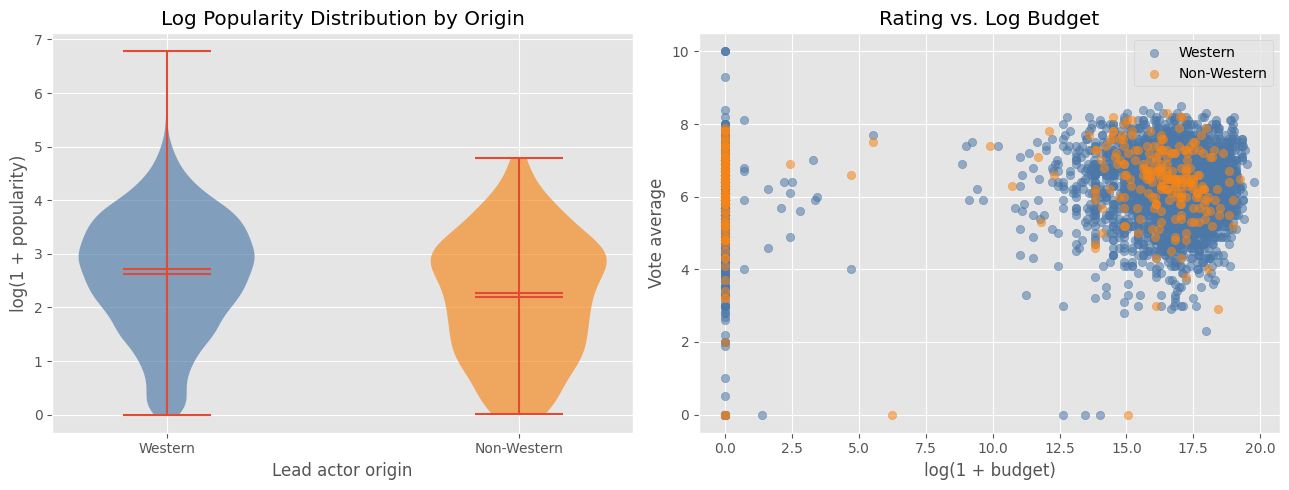

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

popularity_groups = [
    eda_df.loc[eda_df["origin"] == origin, "log_popularity"].dropna()
    for origin in origin_order
]
violins = axes[0].violinplot(popularity_groups, showmeans=True, showmedians=True)
for body, origin in zip(violins["bodies"], origin_order):
    body.set_facecolor(origin_colors[origin])
    body.set_alpha(0.65)
axes[0].set_xticks(range(1, len(origin_order) + 1))
axes[0].set_xticklabels(origin_order)
axes[0].set_title("Log Popularity Distribution by Origin")
axes[0].set_xlabel("Lead actor origin")
axes[0].set_ylabel("log(1 + popularity)")

for origin in origin_order:
    subset = eda_df.loc[eda_df["origin"] == origin]
    axes[1].scatter(
        subset["log_budget"],
        subset["vote_average"],
        alpha=0.55,
        label=origin,
        color=origin_colors[origin]
    )
axes[1].set_title("Rating vs. Log Budget")
axes[1].set_xlabel("log(1 + budget)")
axes[1].set_ylabel("Vote average")
axes[1].legend()

plt.tight_layout()
plt.show()


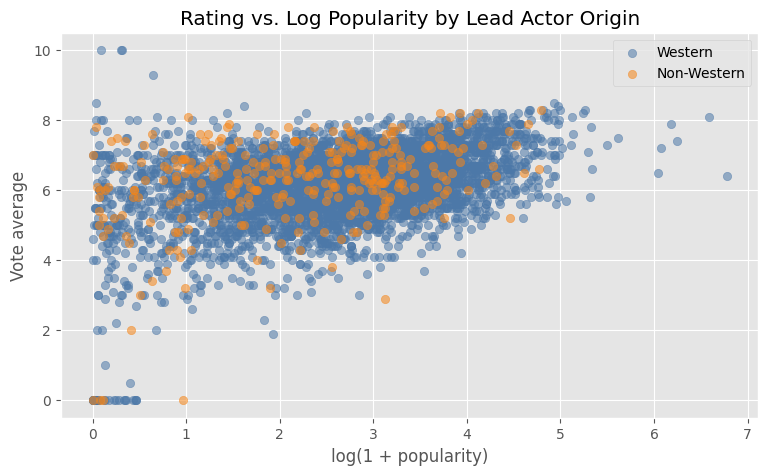

In [19]:
for origin in origin_order:
    subset = eda_df.loc[eda_df["origin"] == origin]
    plt.scatter(
        subset["log_popularity"],
        subset["vote_average"],
        alpha=0.55,
        label=origin,
        color=origin_colors[origin]
    )

plt.title("Rating vs. Log Popularity by Lead Actor Origin")
plt.xlabel("log(1 + popularity)")
plt.ylabel("Vote average")
plt.legend()
plt.show()


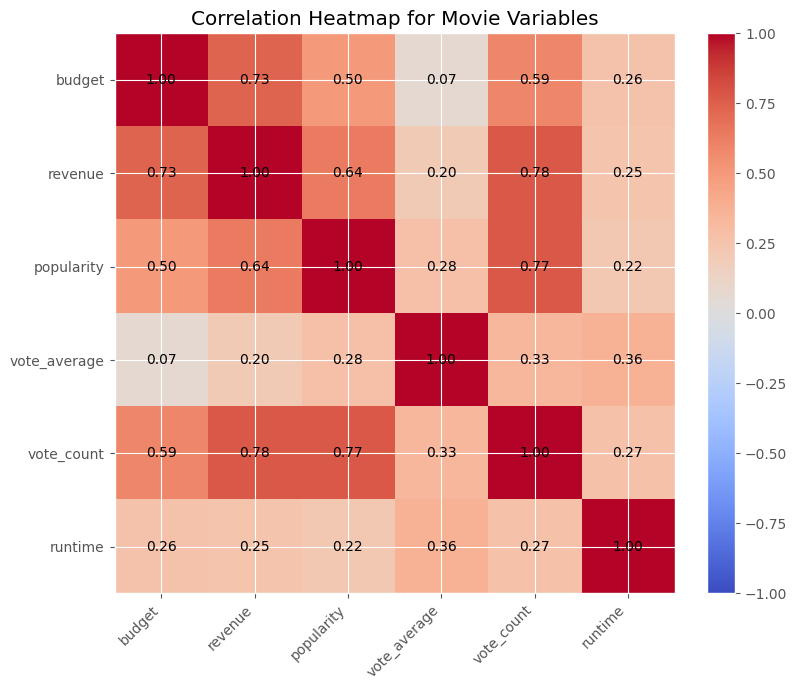

In [20]:
corr_cols = ["budget", "revenue", "popularity", "vote_average", "vote_count", "runtime"]
corr = eda_df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
heatmap = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlation Heatmap for Movie Variables")
plt.tight_layout()
plt.show()


## 6. Hypothesis testing approach

For each comparison, the notebook first checks normality separately for the Western and Non-Western groups. If both groups pass the normality check at alpha = 0.05, Welch's independent samples t-test is used because it does not assume equal variances. If either group does not appear normal, the Mann-Whitney U test is used as a non-parametric alternative.


In [21]:
ALPHA = 0.05


def check_normality(series, label, alpha=ALPHA):
    clean = series.dropna()

    if len(clean) < 3:
        return {
            "group": label,
            "n": len(clean),
            "test": "not enough data",
            "statistic": np.nan,
            "p_value": np.nan,
            "appears_normal": False
        }

    if len(clean) < 8:
        statistic, p_value = shapiro(clean)
        test_name = "Shapiro-Wilk"
    else:
        statistic, p_value = normaltest(clean)
        test_name = "D'Agostino-Pearson"

    return {
        "group": label,
        "n": len(clean),
        "test": test_name,
        "statistic": statistic,
        "p_value": p_value,
        "appears_normal": p_value > alpha
    }


def compare_by_origin(metric, alternative="two-sided", alpha=ALPHA):
    western = df.loc[df["origin"] == "Western", metric].dropna()
    non_western = df.loc[df["origin"] == "Non-Western", metric].dropna()

    normality = pd.DataFrame([
        check_normality(western, "Western", alpha),
        check_normality(non_western, "Non-Western", alpha)
    ])

    both_normal = normality["appears_normal"].all()

    if both_normal:
        statistic, p_value = ttest_ind(
            western,
            non_western,
            equal_var=False,
            alternative=alternative
        )
        selected_test = "Welch independent samples t-test"
    else:
        statistic, p_value = mannwhitneyu(
            western,
            non_western,
            alternative=alternative
        )
        selected_test = "Mann-Whitney U test"

    result = pd.DataFrame([{
        "metric": metric,
        "selected_test": selected_test,
        "alternative": alternative,
        "statistic": statistic,
        "p_value": p_value,
        "reject_H0_at_0.05": p_value < alpha,
        "western_mean": western.mean(),
        "non_western_mean": non_western.mean(),
        "western_median": western.median(),
        "non_western_median": non_western.median()
    }])

    print("Normality check:")
    display(normality.round(4))
    print("Selected statistical test:", selected_test)
    display(result.round(4))

    return normality, result


### Test 1: Budget by lead actor origin

**H0:** Movie budget does not differ between movies with Western and Non-Western lead actors.

**H1:** Movie budget differs between movies with Western and Non-Western lead actors.


In [22]:
budget_normality, budget_test = compare_by_origin("budget", alternative="two-sided")


Normality check:


,group,n,test,statistic,p_value,appears_normal
0,Western,4291,D'Agostino-Pearson,2131.2329,0.0,False
1,Non-Western,325,D'Agostino-Pearson,249.6622,0.0,False


Selected statistical test: Mann-Whitney U test


,metric,selected_test,alternative,statistic,p_value,reject_H0_at_0.05,western_mean,non_western_mean,western_median,non_western_median
0,budget,Mann-Whitney U test,two-sided,853218.0,0.0,True,3.104876e+07,1.803359e+07,16000000.0,7000000.0


### Test 2: Rating by lead actor origin

**H0:** Movies with Non-Western lead actors do not have higher ratings than movies with Western lead actors.

**H1:** Movies with Non-Western lead actors have higher ratings than movies with Western lead actors.

Because `compare_by_origin` passes the Western group first and the Non-Western group second, `alternative="less"` tests whether Western values are lower than Non-Western values.


In [23]:
rating_normality, rating_test = compare_by_origin("vote_average", alternative="less")


Normality check:


,group,n,test,statistic,p_value,appears_normal
0,Western,4291,D'Agostino-Pearson,1490.3620,0.0,False
1,Non-Western,325,D'Agostino-Pearson,163.6954,0.0,False


Selected statistical test: Mann-Whitney U test


,metric,selected_test,alternative,statistic,p_value,reject_H0_at_0.05,western_mean,non_western_mean,western_median,non_western_median
0,vote_average,Mann-Whitney U test,less,606644.5,0.0,True,6.1369,6.284,6.2,6.5


### Test 3: Popularity by lead actor origin

**H0:** Movies with Western lead actors are not more popular than movies with Non-Western lead actors.

**H1:** Movies with Western lead actors are more popular than movies with Non-Western lead actors.

Because `compare_by_origin` passes the Western group first and the Non-Western group second, `alternative="greater"` tests whether Western values are higher than Non-Western values.


In [24]:
popularity_normality, popularity_test = compare_by_origin("popularity", alternative="greater")


Normality check:


,group,n,test,statistic,p_value,appears_normal
0,Western,4291,D'Agostino-Pearson,6731.2021,0.0,False
1,Non-Western,325,D'Agostino-Pearson,192.9784,0.0,False


Selected statistical test: Mann-Whitney U test


,metric,selected_test,alternative,statistic,p_value,reject_H0_at_0.05,western_mean,non_western_mean,western_median,non_western_median
0,popularity,Mann-Whitney U test,greater,844600.0,0.0,True,22.8155,15.3109,14.2319,8.5894


In [25]:
test_summary = pd.concat([budget_test, rating_test, popularity_test], ignore_index=True)
test_summary.round(4)


,metric,selected_test,alternative,statistic,p_value,reject_H0_at_0.05,western_mean,non_western_mean,western_median,non_western_median
0,budget,Mann-Whitney U test,two-sided,853218.0,0.0,True,3.104876e+07,1.803359e+07,1.600000e+07,7.000000e+06
1,vote_average,Mann-Whitney U test,less,606644.5,0.0,True,6.136900e+00,6.284000e+00,6.200000e+00,6.500000e+00
2,popularity,Mann-Whitney U test,greater,844600.0,0.0,True,2.281550e+01,1.531090e+01,1.423190e+01,8.589400e+00


## 7. Linear regression model

A simple linear regression is used as a baseline model for predicting `vote_average` from budget, popularity, and lead actor origin.


In [26]:
ml_df = df[["budget", "popularity", "origin", "vote_average"]].copy()

ml_df["origin_binary"] = ml_df["origin"].map({
    "Western": 1,
    "Non-Western": 0
})

ml_df = ml_df.dropna()
ml_df.head()


,budget,popularity,origin,vote_average,origin_binary
0,237000000,150.437577,Western,7.2,1
1,300000000,139.082615,Western,6.9,1
2,245000000,107.376788,Western,6.3,1
3,250000000,112.312950,Western,7.6,1
4,260000000,43.926995,Western,6.1,1


In [27]:
X = ml_df[["budget", "popularity", "origin_binary"]]
y = ml_df["vote_average"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

linear_mse = mean_squared_error(y_test, y_pred)
linear_r2 = r2_score(y_test, y_pred)

print("Linear Regression MSE:", linear_mse)
print("Linear Regression R2:", linear_r2)


Linear Regression MSE: 1.1830188812112528
Linear Regression R2: 0.028716825817396097


In [28]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients


,Feature,Coefficient
0,budget,-2.846544e-09
1,popularity,1.267097e-02
2,origin_binary,-1.802348e-01


## 8. Decision tree regression model

The decision tree model adds `vote_count`, `runtime`, and log-transformed budget. This allows the model to capture non-linear relationships that the baseline linear regression may miss.


In [29]:
ml_df2 = df[["budget", "popularity", "origin", "vote_average", "vote_count", "runtime"]].copy()

ml_df2["origin_binary"] = ml_df2["origin"].map({
    "Western": 1,
    "Non-Western": 0
})
ml_df2["log_budget"] = np.log1p(ml_df2["budget"])

ml_df2 = ml_df2.dropna()
ml_df2.head()


,budget,popularity,origin,vote_average,vote_count,runtime,origin_binary,log_budget
0,237000000,150.437577,Western,7.2,11800,162.0,1,19.283571
1,300000000,139.082615,Western,6.9,4500,169.0,1,19.519293
2,245000000,107.376788,Western,6.3,4466,148.0,1,19.316769
3,250000000,112.312950,Western,7.6,9106,165.0,1,19.336971
4,260000000,43.926995,Western,6.1,2124,132.0,1,19.376192


In [30]:
X2 = ml_df2[["log_budget", "popularity", "origin_binary", "vote_count", "runtime"]]
y2 = ml_df2["vote_average"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train2, y_train2)
y_pred_tree = tree.predict(X_test2)

tree_mse = mean_squared_error(y_test2, y_pred_tree)
tree_r2 = r2_score(y_test2, y_pred_tree)

print("Decision Tree MSE:", tree_mse)
print("Decision Tree R2:", tree_r2)


Decision Tree MSE: 0.6179237836762829
Decision Tree R2: 0.44537992883535116


In [31]:
model_results = pd.DataFrame([
    {"model": "Linear Regression", "MSE": linear_mse, "R2": linear_r2},
    {"model": "Decision Tree", "MSE": tree_mse, "R2": tree_r2}
])

model_results.round(4)


,model,MSE,R2
0,Linear Regression,1.1830,0.0287
1,Decision Tree,0.6179,0.4454


## 9. Conclusion

The final interpretation should be based on the p-values in the hypothesis test summary and the model comparison table. The normality checks determine whether each hypothesis uses Welch's t-test or the Mann-Whitney U test, which makes the inference more appropriate for skewed variables such as budget and popularity.
